# Mô phỏng OFDM bằng IFFT và FFT

Notebook gồm hai mô phỏng:

1. **IFFT tạo tín hiệu OFDM:** dữ liệu nhị phân được điều chế QPSK trên 64 sóng mang con, biến đổi sang miền thời gian bằng IFFT và thêm cyclic prefix.
2. **FFT khôi phục dữ liệu:** cyclic prefix được loại bỏ, FFT đưa tín hiệu về miền tần số, sau đó giải điều chế QPSK và tính BER.

Mô phỏng dùng kênh lý tưởng để thể hiện trực tiếp tính chất $\mathrm{FFT}(\mathrm{IFFT}(X))=X$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

# Tham số hệ thống OFDM
N = 64                 # Số sóng mang con
N_CP = 16             # Độ dài cyclic prefix
SEED = 1              # Cố định để kết quả có thể lặp lại
rng = np.random.default_rng(SEED)

print(f'Số sóng mang con N = {N}')
print(f'Độ dài cyclic prefix = {N_CP} mẫu')

Số sóng mang con N = 64
Độ dài cyclic prefix = 16 mẫu


## Mô phỏng 1: IFFT tạo tín hiệu OFDM

Mỗi sóng mang con mang một ký hiệu QPSK. NumPy sử dụng cùng quy ước chuẩn như MATLAB: `ifft` chứa hệ số $1/N$, còn `fft` không chia cho $N$.

MÔ PHỎNG 1: IFFT TẠO TÍN HIỆU OFDM
Số bit đầu vào            : 128
Số ký hiệu QPSK           : 64
Độ dài tín hiệu phát      : 80 mẫu
PAPR của ký hiệu OFDM     : 6.546 dB


/tmp/ipykernel_1602/728039330.py:63: UserWarning: Glyph 7919 (\N{LATIN SMALL LETTER U WITH HORN AND TILDE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/728039330.py:63: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/728039330.py:63: UserWarning: Glyph 7881 (\N{LATIN SMALL LETTER I WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/728039330.py:63: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/728039330.py:63: UserWarning: Glyph 7873 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/728039330.py:63: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation S

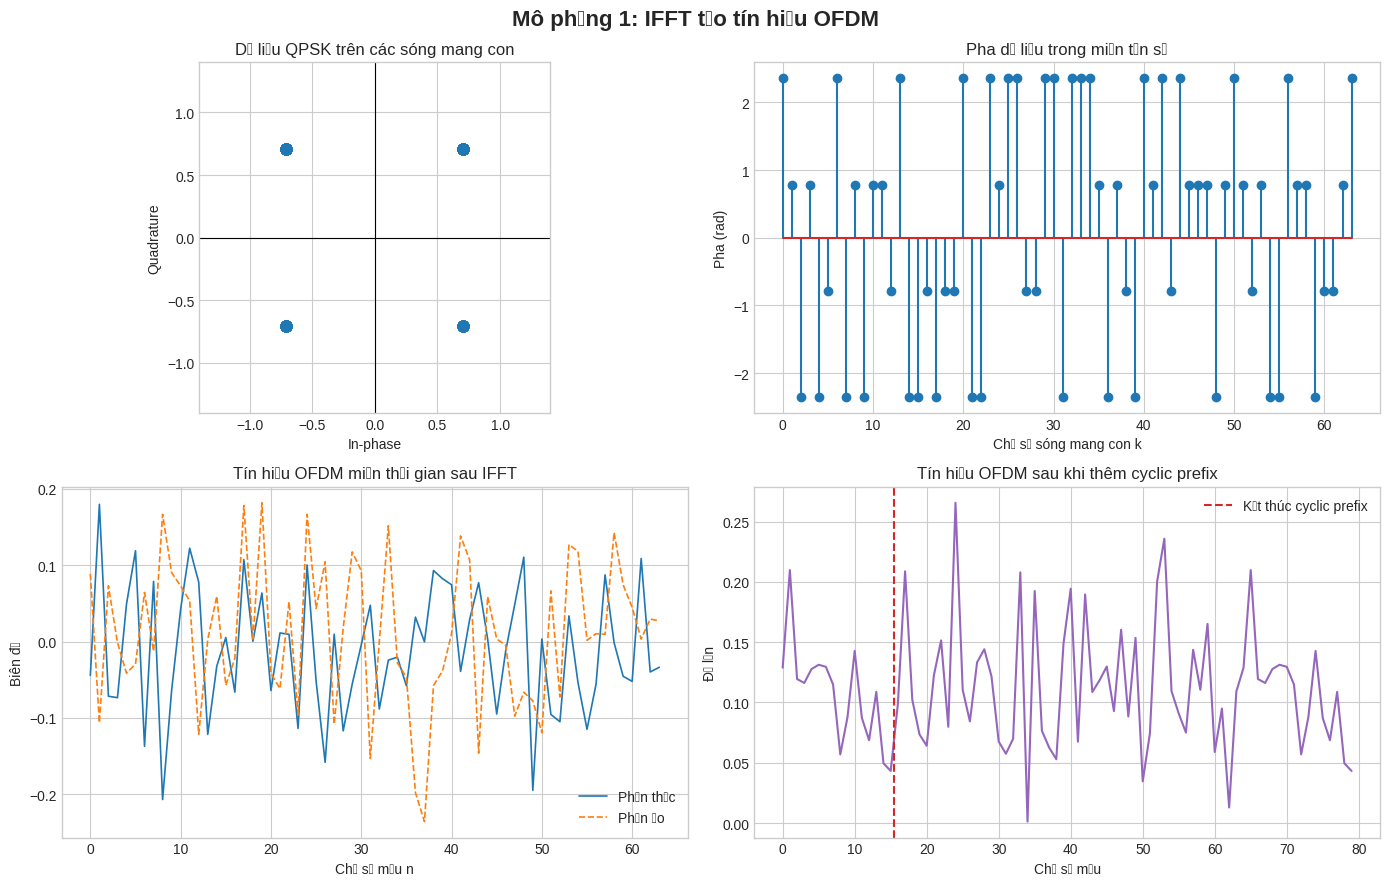

In [2]:
# Sinh hai bit cho mỗi sóng mang con
tx_bits = rng.integers(0, 2, size=(N, 2))

# Điều chế QPSK: biên độ trung bình được chuẩn hóa về 1
in_phase = 2 * tx_bits[:, 0] - 1
quadrature = 2 * tx_bits[:, 1] - 1
X = (in_phase + 1j * quadrature) / np.sqrt(2)

# IFFT: chuyển dữ liệu từ miền tần số sang miền thời gian
x_ofdm = np.fft.ifft(X, n=N)

# Thêm cyclic prefix
cyclic_prefix = x_ofdm[-N_CP:]
tx_signal = np.concatenate([cyclic_prefix, x_ofdm])

# Tính PAPR của phần ký hiệu OFDM hữu ích
papr_db = 10 * np.log10(
    np.max(np.abs(x_ofdm) ** 2) / np.mean(np.abs(x_ofdm) ** 2)
)

print('MÔ PHỎNG 1: IFFT TẠO TÍN HIỆU OFDM')
print(f'Số bit đầu vào            : {tx_bits.size}')
print(f'Số ký hiệu QPSK           : {len(X)}')
print(f'Độ dài tín hiệu phát      : {len(tx_signal)} mẫu')
print(f'PAPR của ký hiệu OFDM     : {papr_db:.3f} dB')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(X.real, X.imag, s=60, color='tab:blue')
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].axvline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Dữ liệu QPSK trên các sóng mang con')
axes[0, 0].set_xlabel('In-phase')
axes[0, 0].set_ylabel('Quadrature')
axes[0, 0].set_aspect('equal', adjustable='box')
axes[0, 0].set_xlim(-1.4, 1.4)
axes[0, 0].set_ylim(-1.4, 1.4)

k = np.arange(N)
axes[0, 1].stem(k, np.angle(X))
axes[0, 1].set_title('Pha dữ liệu trong miền tần số')
axes[0, 1].set_xlabel('Chỉ số sóng mang con k')
axes[0, 1].set_ylabel('Pha (rad)')

n = np.arange(N)
axes[1, 0].plot(n, x_ofdm.real, label='Phần thực', linewidth=1.2)
axes[1, 0].plot(n, x_ofdm.imag, '--', label='Phần ảo', linewidth=1.2)
axes[1, 0].set_title('Tín hiệu OFDM miền thời gian sau IFFT')
axes[1, 0].set_xlabel('Chỉ số mẫu n')
axes[1, 0].set_ylabel('Biên độ')
axes[1, 0].legend()

n_cp = np.arange(len(tx_signal))
axes[1, 1].plot(n_cp, np.abs(tx_signal), color='tab:purple')
axes[1, 1].axvline(N_CP - 0.5, color='tab:red', linestyle='--',
                   label='Kết thúc cyclic prefix')
axes[1, 1].set_title('Tín hiệu OFDM sau khi thêm cyclic prefix')
axes[1, 1].set_xlabel('Chỉ số mẫu')
axes[1, 1].set_ylabel('Độ lớn')
axes[1, 1].legend()

fig.suptitle('Mô phỏng 1: IFFT tạo tín hiệu OFDM', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

## Mô phỏng 2: FFT khôi phục dữ liệu

Tín hiệu được truyền qua kênh lý tưởng. Máy thu loại bỏ cyclic prefix, thực hiện FFT, ra quyết định QPSK theo dấu của phần thực và phần ảo, rồi so sánh với dữ liệu ban đầu.

MÔ PHỎNG 2: FFT KHÔI PHỤC DỮ LIỆU
Sai số tuyệt đối lớn nhất : 4.965e-16
Số bit lỗi                 : 0/128
BER                        : 0.000000
Kết luận: FFT đã khôi phục chính xác toàn bộ dữ liệu.


/tmp/ipykernel_1602/1662810142.py:81: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/1662810142.py:81: UserWarning: Glyph 7909 (\N{LATIN SMALL LETTER U WITH DOT BELOW}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/1662810142.py:81: UserWarning: Glyph 7881 (\N{LATIN SMALL LETTER I WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/1662810142.py:81: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/1662810142.py:81: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_1602/1662810142.py:81: UserWarning: Glyph 7921 (\N{LATIN SMALL LETTER U WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sa

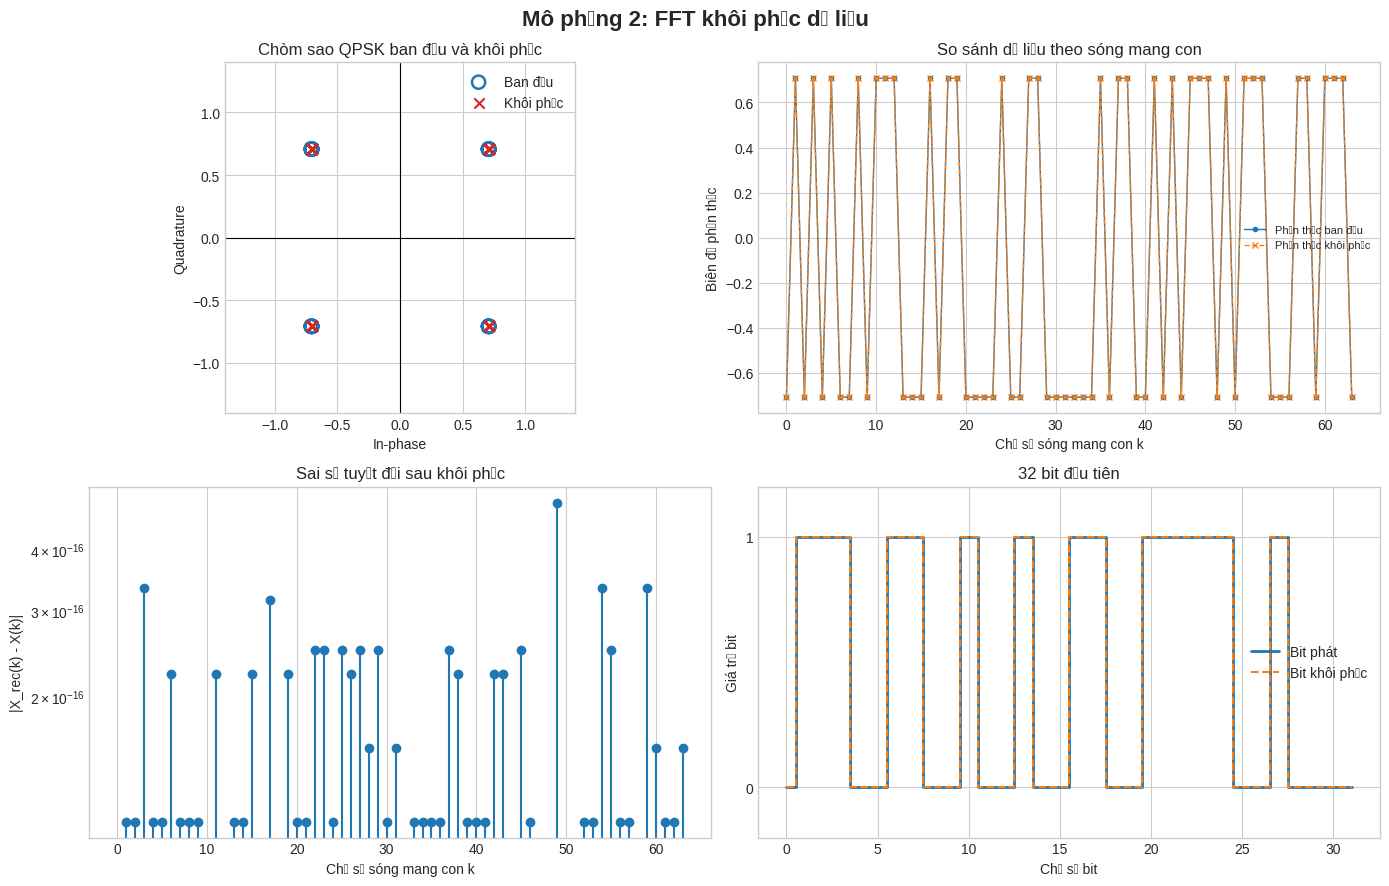

In [3]:
# Kênh lý tưởng
rx_signal = tx_signal.copy()

# Loại bỏ cyclic prefix
rx_without_cp = rx_signal[N_CP:N_CP + N]

# FFT: khôi phục dữ liệu trong miền tần số
X_recovered = np.fft.fft(rx_without_cp, n=N)

# Giải điều chế QPSK bằng quyết định cứng
rx_bits = np.column_stack((
    (X_recovered.real >= 0).astype(int),
    (X_recovered.imag >= 0).astype(int)
))

# Các chỉ tiêu kiểm tra
recovery_error = X_recovered - X
max_abs_error = np.max(np.abs(recovery_error))
num_bit_errors = np.count_nonzero(rx_bits != tx_bits)
ber = num_bit_errors / tx_bits.size

print('MÔ PHỎNG 2: FFT KHÔI PHỤC DỮ LIỆU')
print(f'Sai số tuyệt đối lớn nhất : {max_abs_error:.3e}')
print(f'Số bit lỗi                 : {num_bit_errors}/{tx_bits.size}')
print(f'BER                        : {ber:.6f}')

if num_bit_errors == 0:
    print('Kết luận: FFT đã khôi phục chính xác toàn bộ dữ liệu.')
else:
    print('Kết luận: Có lỗi trong dữ liệu khôi phục.')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(X.real, X.imag, s=90, facecolors='none',
                   edgecolors='tab:blue', linewidths=1.8, label='Ban đầu')
axes[0, 0].scatter(X_recovered.real, X_recovered.imag, s=55,
                   marker='x', color='tab:red', linewidths=1.5,
                   label='Khôi phục')
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].axvline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Chòm sao QPSK ban đầu và khôi phục')
axes[0, 0].set_xlabel('In-phase')
axes[0, 0].set_ylabel('Quadrature')
axes[0, 0].set_aspect('equal', adjustable='box')
axes[0, 0].set_xlim(-1.4, 1.4)
axes[0, 0].set_ylim(-1.4, 1.4)
axes[0, 0].legend()

axes[0, 1].plot(k, X.real, 'o-', markersize=3, linewidth=1,
                label='Phần thực ban đầu')
axes[0, 1].plot(k, X_recovered.real, 'x--', markersize=4, linewidth=1,
                label='Phần thực khôi phục')
axes[0, 1].set_title('So sánh dữ liệu theo sóng mang con')
axes[0, 1].set_xlabel('Chỉ số sóng mang con k')
axes[0, 1].set_ylabel('Biên độ phần thực')
axes[0, 1].legend(fontsize=8)

axes[1, 0].stem(k, np.abs(recovery_error))
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Sai số tuyệt đối sau khôi phục')
axes[1, 0].set_xlabel('Chỉ số sóng mang con k')
axes[1, 0].set_ylabel('|X_rec(k) - X(k)|')

number_of_displayed_bits = 32
tx_bits_flat = tx_bits.reshape(-1)
rx_bits_flat = rx_bits.reshape(-1)
bit_index = np.arange(number_of_displayed_bits)
axes[1, 1].step(bit_index, tx_bits_flat[:number_of_displayed_bits],
                where='mid', linewidth=2, label='Bit phát')
axes[1, 1].step(bit_index, rx_bits_flat[:number_of_displayed_bits],
                where='mid', linestyle='--', linewidth=1.5,
                label='Bit khôi phục')
axes[1, 1].set_title('32 bit đầu tiên')
axes[1, 1].set_xlabel('Chỉ số bit')
axes[1, 1].set_ylabel('Giá trị bit')
axes[1, 1].set_ylim(-0.2, 1.2)
axes[1, 1].set_yticks([0, 1])
axes[1, 1].legend()

fig.suptitle('Mô phỏng 2: FFT khôi phục dữ liệu', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

## Kết luận

Trong kênh lý tưởng, FFT khôi phục các ký hiệu QPSK với BER bằng 0. Sai số còn lại chỉ ở mức làm tròn số thực dấu phẩy động. Cyclic prefix không làm thay đổi dữ liệu hữu ích vì nó được loại bỏ trước FFT.